<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-03 | train loss 1.3885 acc 0.355 | val loss 1.3897 acc 0.100 *


[AlexNet] Epoch   2/100 | LR: 1.00e-03 | train loss 1.3880 acc 0.370 | val loss 1.3963 acc 0.222


[AlexNet] Epoch   3/100 | LR: 1.00e-03 | train loss 1.3022 acc 0.421 | val loss 1.2149 acc 0.453 *


[AlexNet] Epoch   4/100 | LR: 1.00e-03 | train loss 1.3433 acc 0.408 | val loss 1.2206 acc 0.453


...

[AlexNet] Epoch  96/100 | LR: 1.00e-09 | train loss 0.6986 acc 0.668 | val loss 0.7413 acc 0.680


[AlexNet] Epoch  97/100 | LR: 1.00e-09 | train loss 0.7242 acc 0.677 | val loss 0.7412 acc 0.680 *


[AlexNet] Epoch  98/100 | LR: 1.00e-09 | train loss 0.7070 acc 0.686 | val loss 0.7413 acc 0.680


[AlexNet] Epoch  99/100 | LR: 1.00e-09 | train loss 0.7051 acc 0.676 | val loss 0.7413 acc 0.680


[AlexNet] Epoch 100/100 | LR: 1.00e-09 | train loss 0.7487 acc 0.669 | val loss 0.7413 acc 0.680

[AlexNet] Restored best checkpoint (val loss = 0.7412)


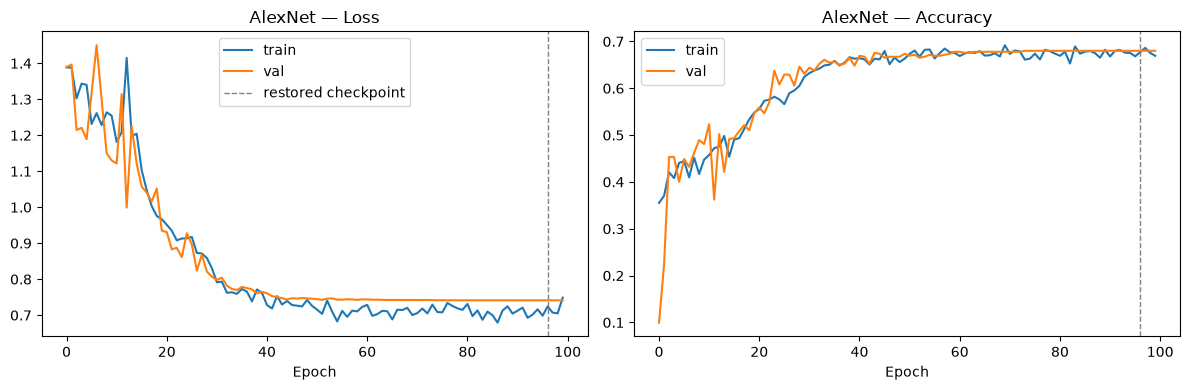

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.567


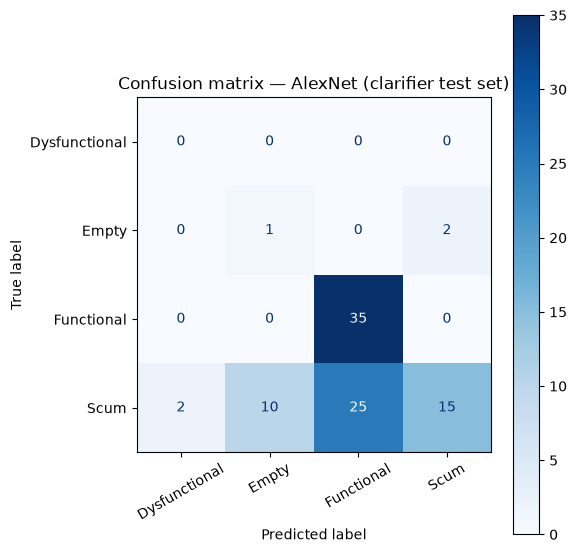

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      0.091     0.333     0.143         3
   Functional      0.583     1.000     0.737        35
         Scum      0.882     0.288     0.435        52

     accuracy                          0.567        90
    macro avg      0.389     0.405     0.329        90
 weighted avg      0.740     0.567     0.543        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


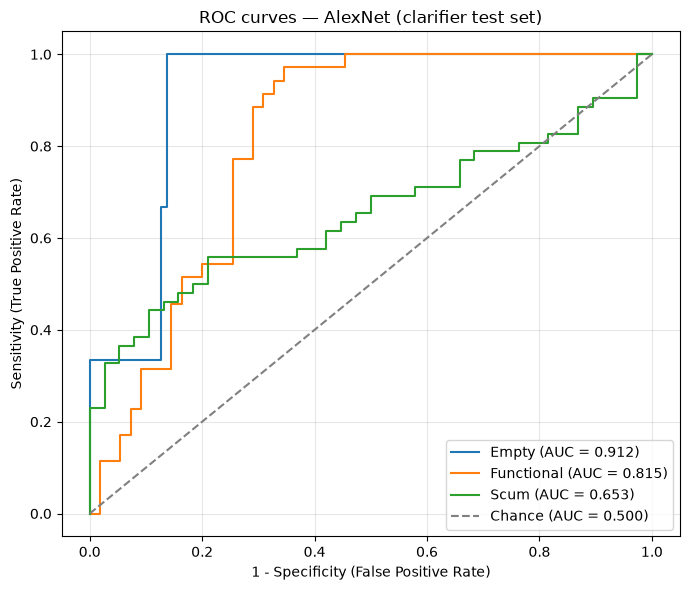

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 0.912
  Functional     : 0.815
  Scum           : 0.653

Mean AUC (over 3/4 classes with test examples): 0.793


(np.float64(0.5666666666666667),
 {'Dysfunctional': nan,
  'Empty': 0.9118773946360152,
  'Functional': 0.8145454545454545,
  'Scum': 0.652834008097166})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/results_clarifier_alexnet_Atlantis.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
